In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from src.custom_kfold import CustomKFold
from src.sdee_statistics import calculate_nmae, calculate_mae
from src.train_dataset import get_X_y, train_model_cv
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import (
    SelectPercentile,
    f_regression,
    mutual_info_regression,
)
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import mutual_info_regression
import json
from src.get_folds_results import get_fold_results
from src.plot_results import plot_feature_frequency_per_fold


In [4]:
# load dataset heads:
dataset_iteration_30 = pd.read_csv("datasets/apache_iteration_30_features.csv")
dataset_iteration_30.head(1)

# setup model:
X, y = get_X_y(dataset_iteration_30)

custom_kfold = CustomKFold(n_splits=10, shuffle=False)
nmae_scorer = make_scorer(calculate_nmae, greater_is_better=False)
mae_scorer = make_scorer(calculate_mae, greater_is_better=False)

# train model
random_forest = RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42)

### Regression without feature selection

In [5]:
#nmae_values = train_model_cv(X, y, random_forest, custom_kfold)


nmae_values = cross_val_score(random_forest, X, y, cv=custom_kfold, scoring=mae_scorer) 
print(f"Avg nmae: {sum(nmae_values) / len(nmae_values)}")

Avg nmae: -4.774040294782896


### Feature importances

nº features: 97


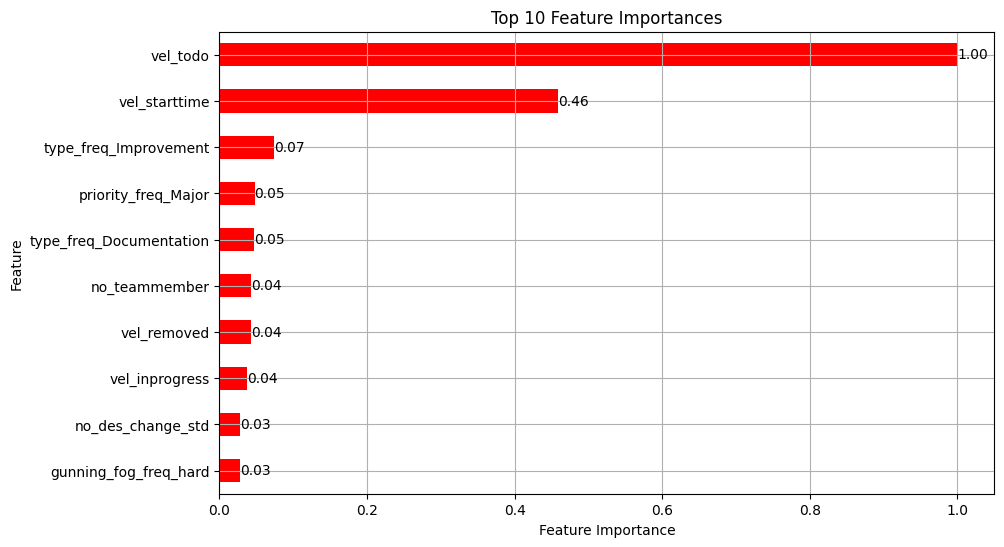

In [6]:
def get_feature_importances(random_forest, X):
    return pd.Series(random_forest.feature_importances_, index=X.columns)


def scale_features(feature_importance_series):
    scaler = MinMaxScaler()
    feature_importances_normalized = scaler.fit_transform(
        feature_importance_series.values.reshape(-1, 1)
    ).flatten()
    feature_importances_normalized = pd.Series(
        feature_importances_normalized, index=feature_importance_series.index
    )
    return feature_importances_normalized


def plot_feature_importances(feature_importances, top_n=10):
    feature_importances = feature_importances.sort_values(ascending=False)[:top_n]

    plt.figure(figsize=(10, 6))
    plt.title("Top 10 Feature Importances")
    feature_importances.plot(kind="barh", color="r")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.grid()
    plt.gca().invert_yaxis()  # Invert y-axis to have the most relevant feature at the top
    # Annotate each bar with its value
    for i, value in enumerate(feature_importances):
        plt.text(value, i, f"{value:.2f}", ha="left", va="center")
    plt.show()


random_forest.fit(X, y)
print(f"nº features: {len(random_forest.feature_importances_)}")
# get the feature ranking of the rf model:
feature_importances = get_feature_importances(random_forest, X)

feature_importances_normalized = scale_features(feature_importances)
plot_feature_importances(feature_importances_normalized)

#### Feature selection by percentile of random forest best features

In [8]:
X, y = get_X_y(dataset_iteration_30)


def custom_scorer(X, y):
    random_forest.fit(X, y)
    return random_forest.feature_importances_


percentiles = [20, 40, 60]
for percentile in percentiles:
    print(f"Training model for {percentile}% of the features:")
    pipeline = Pipeline(
        [
            (
                "feature_selection",
                SelectPercentile(percentile=percentile, score_func=custom_scorer),
            ),
            ("regressor", random_forest),
        ]
    )

    #nmae_values = cross_val_score(pipeline, X, y, cv=custom_kfold, scoring=mae_scorer)
    #print(f"avg nmae: {sum(nmae_values) / len(nmae_values)}")
    execution_result = get_fold_results(
        pipeline,
        cv=custom_kfold,
        X=X,
        y=y,
        config_text=f"SelectPercentile {percentile}%",
    )
    print(execution_result["config"], execution_result["mae_avg"])
    plt = plot_feature_frequency_per_fold(execution_result)
    print("=" * 40)

Training model for 20% of the features:


KeyboardInterrupt: 

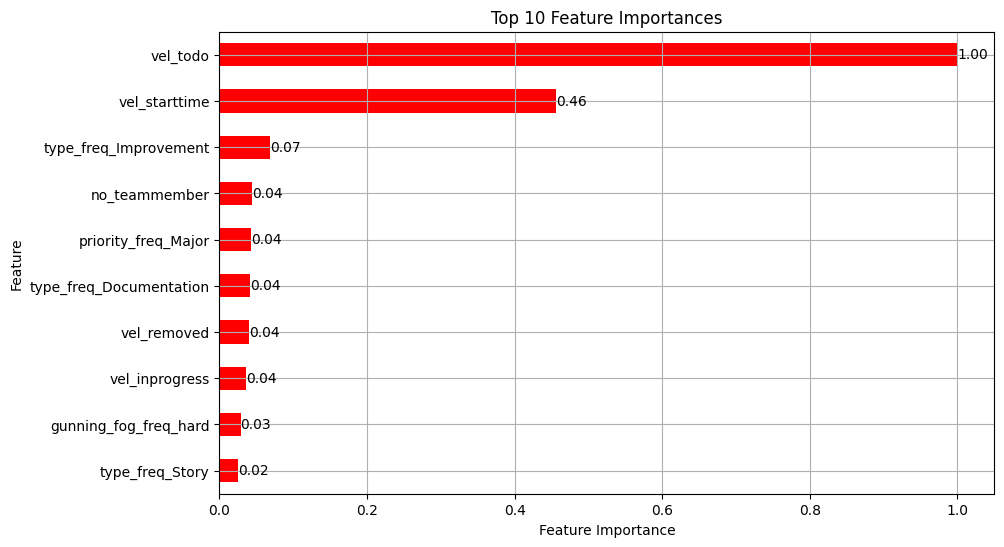

In [6]:
# result of features:
pipeline.fit(X,y)
selected_feature_indices = pipeline.named_steps["feature_selection"].get_support(
    indices=True
)
feature_importances=pipeline.named_steps["regressor"].feature_importances_

feature_importance_dict = {}

for index, importance in zip(selected_feature_indices, feature_importances):
    feature_name = X.columns[index]
    feature_importance_dict[feature_name] = importance

feature_importances = pd.Series(feature_importance_dict)

feature_importances_normalized = scale_features(feature_importances)

plot_feature_importances(feature_importances_normalized)

### Feature selection by Sequential Forward Search

tol=1 direction=backward n_features_to_select=0.2


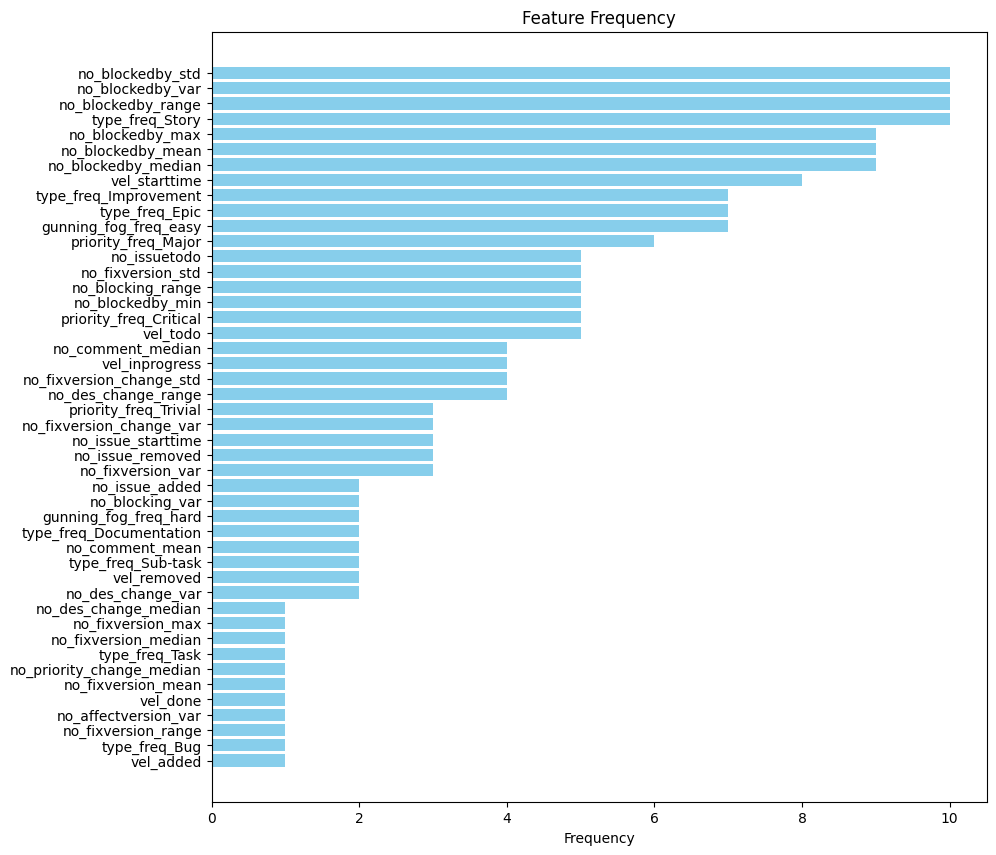

In [26]:
# execution run in galgo
with open(f"outputs/merged_output.json") as output_file:
    sequential_outputs = json.load(output_file)
    best_config = max_element = min(sequential_outputs, key=lambda x: x['mae_avg'])
    print(best_config["config"])

last_fold = best_config['folds'][-1]

# Sorting the features by importance and selecting the top 10
sorted_features = sorted(last_fold['features'].items(), key=lambda x: x[1], reverse=True)[:]

# Unpacking the feature names and their importances
features, importances = zip(*sorted_features)

# Plotting the horizontal bar chart
plt.figure(figsize=(10, 10))
plt.barh(features, importances, color='skyblue')
plt.xlabel('Frequency')
plt.title('Feature Frequency')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest importance on top
plt.show()


In [23]:
print(f"Sequential Forward Search:")
sfs_pipeline = Pipeline(
    [
        (
            "feature_selection",
            SequentialFeatureSelector(
                random_forest,
                n_features_to_select=0.2,
                cv=custom_kfold,
                n_jobs=-1,
                scoring=nmae_scorer,
            ),
        ),
        ("regressor", random_forest),
    ]
)

nmae_values = cross_val_score(sfs_pipeline, X, y, cv=custom_kfold, scoring=nmae_scorer)
print(f"avg nmae: {sum(nmae_values) / len(nmae_values)}")
print("=" * 40)

Sequential Forward Search:


c:\Users\viktitors\repos\sdee\venv\lib\site-packages\sklearn\base.py:365: RuntimeWarning: coroutine 'InteractiveShell.run_cell_async' was never awaited
  state = self.__dict__.copy()


In [ ]:
# result of features:
sfs_pipeline.fit(X,y)
selected_feature_indices = sfs_pipeline.named_steps["feature_selection"].get_support(
    indices=True
)
feature_importances=sfs_pipeline.named_steps["regressor"].feature_importances_

feature_importance_dict = {}

for index, importance in zip(selected_feature_indices, feature_importances):
    feature_name = X.columns[index]
    feature_importance_dict[feature_name] = importance

feature_importances = pd.Series(feature_importance_dict)

feature_importances_normalized = scale_features(feature_importances)

plot_feature_importances(feature_importances_normalized)

In [12]:
sfs = SequentialFeatureSelector(
    RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42),
    n_features_to_select=0.2,
    cv=custom_kfold,
    n_jobs=-1,
    scoring=make_scorer(calculate_nmae, greater_is_better=False),
)

sfs.fit(X, y)
print(sfs.get_support())

[False  True False False  True False False False False False False False
 False False False  True False False False False False False False False
 False False  True False False False False False False False False False
  True False False False False False False False False False False False
 False False False False False False False False False False False False
 False  True False  True  True False False False  True  True False False
 False False  True  True False  True  True False False False False False
 False  True  True  True  True False False False False False False  True
 False]


In [19]:
selected_feature_indices = sfs.get_support()
feature_names = X.columns[selected_feature_indices]
print(feature_names)

reduced_features_X = sfs.transform(X)
nmae_values = cross_val_score(RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42), reduced_features_X, y, cv=custom_kfold, scoring=nmae_scorer)
print(f"avg nmae: {sum(nmae_values) / len(nmae_values)}")
print("=" * 40)

Index(['vel_starttime', 'no_issue_removed', 'type_freq_Improvement',
       'no_affectversion_min', 'no_fixversion_median',
       'no_fixversion_change_min', 'no_fixversion_change_mean',
       'no_fixversion_change_median', 'no_priority_change_min',
       'no_priority_change_max', 'no_priority_change_range',
       'no_des_change_min', 'no_des_change_mean', 'no_des_change_median',
       'type_freq_Epic', 'priority_freq_Critical', 'type_freq_Story',
       'priority_freq_Trivial', 'type_freq_Test'],
      dtype='object')
avg nmae: -0.32192208342825185


In [ ]:
from src.telegram_notifier import send_telegram_message


send_telegram_message()